<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/Patient_RandomSurvivalForest_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!pip install -q scikit-survival

In [9]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.model_selection import ParameterGrid

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score
)
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv

warnings.filterwarnings("ignore")


BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/Clinical Patient/"
    "survival_model_ready_wout_protocol"
)

TRAIN_PATH = BASE_DIR / "train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "test_survival_model_ready.csv"

OUTPUT_DIR = BASE_DIR / "random_survival_forest_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Train:", TRAIN_PATH)
print("Validation:", VALIDATION_PATH)
print("Test:", TEST_PATH)
print("Results:", OUTPUT_DIR)

Train: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/train_survival_model_ready.csv
Validation: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/validation_survival_model_ready.csv
Test: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/test_survival_model_ready.csv
Results: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/survival_model_ready_wout_protocol/random_survival_forest_results


In [10]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Training shape: (620, 43)
Validation shape: (177, 43)
Test shape: (89, 43)


In [11]:
DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"
PATIENT_ID_COL = "PATIENT_ID"

In [12]:
def describe_survival_dataset(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("Patients:", len(df))
    print("Observed events:", int(df[EVENT_COL].sum()))
    print("Censored:", int((df[EVENT_COL] == 0).sum()))
    print("Event rate:", round(df[EVENT_COL].mean(), 4))
    print("Median follow-up:", round(df[DURATION_COL].median(), 2))
    print(
        "Survival-time range:",
        df[DURATION_COL].min(),
        "to",
        df[DURATION_COL].max(),
        "days"
    )
    print("Missing values:", int(df.isna().sum().sum()))


describe_survival_dataset(train_df, "Training set")
describe_survival_dataset(validation_df, "Validation set")
describe_survival_dataset(test_df, "Test set")


Training set
------------
Patients: 620
Observed events: 223
Censored: 397
Event rate: 0.3597
Median follow-up: 1675.0
Survival-time range: 1.0 to 4127.0 days
Missing values: 0

Validation set
--------------
Patients: 177
Observed events: 63
Censored: 114
Event rate: 0.3559
Median follow-up: 1687.0
Survival-time range: 1.0 to 4022.0 days
Missing values: 0

Test set
--------
Patients: 89
Observed events: 32
Censored: 57
Event rate: 0.3596
Median follow-up: 1610.0
Survival-time range: 8.0 to 3249.0 days
Missing values: 0


In [13]:
continuous_features = [
    "AGE",
    "BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE",
    "PERIPHERAL_BLASTS_PERCENTAGE",
    "WBC_LOG1P"
]

clinical_categorical_features = [
    # Female is the reference
    "SEX_Male",

    # White is the reference
    "RACE_American Indian or Alaska Native",
    "RACE_Asian",
    "RACE_Black or African American",
    "RACE_Native Hawaiian or other Pacific Islander",
    "RACE_Other",

    # Not Hispanic or Latino is the reference
    "ETHNICITY_Hispanic or Latino",

    # No is the reference
    "CNS_DISEASE_Yes",
    "CHLOROMA_Yes",

    # FAB NOS is the reference
    "FAB_M0",
    "FAB_M1",
    "FAB_M2",
    "FAB_M4",
    "FAB_M5",
    "FAB_M6",
    "FAB_M7"
]
risk_features = [
    "RISK_GROUP_CLEAN_Standard",
    "RISK_GROUP_CLEAN_High"
]
cytogenetic_features = [
    # Primary cytogenetic code: Normal is the reference
    "PRIMARY_CYTOGENETIC_CODE_MLL",
    "PRIMARY_CYTOGENETIC_CODE_Other",
    "PRIMARY_CYTOGENETIC_CODE_inv(16)",
    "PRIMARY_CYTOGENETIC_CODE_t(8;21)",

    # Complexity group 0 is the reference
    "CYTOGENETIC_COMPLEXITY_GROUP_1",
    "CYTOGENETIC_COMPLEXITY_GROUP_2",
    "CYTOGENETIC_COMPLEXITY_GROUP_3",
    "CYTOGENETIC_COMPLEXITY_GROUP_4_plus"
]

In [14]:
clinical_features = (
    continuous_features
    + clinical_categorical_features
)

clinical_risk_features = (
    clinical_features
    + risk_features
)

clinical_cytogenetic_features = (
    clinical_features
    + cytogenetic_features
)

FEATURE_SETS = {
    "Clinical": clinical_features,
    "Clinical + Risk": clinical_risk_features,
    "Clinical + Cytogenetics": clinical_cytogenetic_features
}

In [164]:
#change this
FEATURE_SET_NAME = "Clinical + Cytogenetics"

selected_features = FEATURE_SETS[FEATURE_SET_NAME]

print("Selected feature set:", FEATURE_SET_NAME)
print("Number of predictors:", len(selected_features))

for feature in selected_features:
    print("-", feature)

Selected feature set: Clinical + Cytogenetics
Number of predictors: 28
- AGE
- BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE
- PERIPHERAL_BLASTS_PERCENTAGE
- WBC_LOG1P
- SEX_Male
- RACE_American Indian or Alaska Native
- RACE_Asian
- RACE_Black or African American
- RACE_Native Hawaiian or other Pacific Islander
- RACE_Other
- ETHNICITY_Hispanic or Latino
- CNS_DISEASE_Yes
- CHLOROMA_Yes
- FAB_M0
- FAB_M1
- FAB_M2
- FAB_M4
- FAB_M5
- FAB_M6
- FAB_M7
- PRIMARY_CYTOGENETIC_CODE_MLL
- PRIMARY_CYTOGENETIC_CODE_Other
- PRIMARY_CYTOGENETIC_CODE_inv(16)
- PRIMARY_CYTOGENETIC_CODE_t(8;21)
- CYTOGENETIC_COMPLEXITY_GROUP_1
- CYTOGENETIC_COMPLEXITY_GROUP_2
- CYTOGENETIC_COMPLEXITY_GROUP_3
- CYTOGENETIC_COMPLEXITY_GROUP_4_plus


In [165]:
def filter_for_feature_set(df, feature_set_name):
    filtered_df = df.copy()

    if feature_set_name == "Clinical + Risk":
        missing_col = "RISK_GROUP_CLEAN_Missing"

        if missing_col in filtered_df.columns:
            n_removed = int(filtered_df[missing_col].sum())

            filtered_df = filtered_df.loc[
                filtered_df[missing_col] == 0
            ].copy()

            print(
                f"Removed {n_removed} patients with missing "
                f"risk group."
            )

    return filtered_df


In [166]:
train_selected_df = filter_for_feature_set(
    train_df,
    FEATURE_SET_NAME
)

validation_selected_df = filter_for_feature_set(
    validation_df,
    FEATURE_SET_NAME
)

test_selected_df = filter_for_feature_set(
    test_df,
    FEATURE_SET_NAME
)

print("\nRemaining patients")
print("Train:", len(train_selected_df))
print("Validation:", len(validation_selected_df))
print("Test:", len(test_selected_df))


Remaining patients
Train: 620
Validation: 177
Test: 89


In [167]:
required_columns = (
    [PATIENT_ID_COL]
    + selected_features
    + [DURATION_COL, EVENT_COL]
)

def check_columns(df, name):
    missing = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{name} is missing columns:\n"
            + "\n".join(missing)
        )

    print(f"{name}: all required columns are available.")


check_columns(train_selected_df, "Training set")
check_columns(validation_selected_df, "Validation set")
check_columns(test_selected_df, "Test set")

Training set: all required columns are available.
Validation set: all required columns are available.
Test set: all required columns are available.


In [168]:
def prepare_predictors(df, features):
    X = df[features].copy()

    for column in X.columns:
        X[column] = pd.to_numeric(
            X[column],
            errors="coerce"
        )

    if X.isna().any().any():
        problematic = X.columns[X.isna().any()].tolist()

        raise ValueError(
            "Missing or non-numeric predictor values found in: "
            f"{problematic}"
        )

    return X.astype(float)

In [169]:
def prepare_survival_outcome(df):
    if (df[DURATION_COL] <= 0).any():
        raise ValueError("OS_DAYS must be greater than zero.")

    if not df[EVENT_COL].isin([0, 1]).all():
        raise ValueError("OS_EVENT must contain only 0 and 1.")

    return Surv.from_arrays(
        event=df[EVENT_COL].astype(bool).values,
        time=df[DURATION_COL].astype(float).values
    )

In [170]:
X_train = prepare_predictors(
    train_selected_df,
    selected_features
)

X_validation = prepare_predictors(
    validation_selected_df,
    selected_features
)

X_test = prepare_predictors(
    test_selected_df,
    selected_features
)

y_train = prepare_survival_outcome(train_selected_df)
y_validation = prepare_survival_outcome(validation_selected_df)
y_test = prepare_survival_outcome(test_selected_df)

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (620, 28)
X_validation: (177, 28)
X_test: (89, 28)


In [223]:
RSF_PARAMETERS = {
    "n_estimators": 500,
    "max_depth": 10,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "bootstrap": True,
    "oob_score": True,
    "n_jobs": -1,
    "random_state": 42
}

In [224]:
rsf = RandomSurvivalForest(**RSF_PARAMETERS)

rsf.fit(X_train, y_train)

print("Model fitted successfully.")
print("Out-of-bag C-index:", round(rsf.oob_score_, 4))

Model fitted successfully.
Out-of-bag C-index: 0.6332


In [226]:
def calculate_c_index(model, X, y, dataset_name):
    risk_scores = model.predict(X)

    c_index = concordance_index_censored(
        y["event"],
        y["time"],
        risk_scores
    )[0]

    print(f"{dataset_name} C-index: {c_index:.4f}")

    return c_index, risk_scores

In [227]:
train_cindex, train_risk = calculate_c_index(
    rsf,
    X_train,
    y_train,
    "Training"
)

validation_cindex, validation_risk = calculate_c_index(
    rsf,
    X_validation,
    y_validation,
    "Validation"
)

test_cindex, test_risk = calculate_c_index(
    rsf,
    X_test,
    y_test,
    "Test"
)

Training C-index: 0.8413
Validation C-index: 0.6498
Test C-index: 0.6818


In [228]:
cindex_results = pd.DataFrame({
    "dataset": ["Training", "Validation", "Test"],
    "n_patients": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "n_events": [
        int(y_train["event"].sum()),
        int(y_validation["event"].sum()),
        int(y_test["event"].sum())
    ],
    "c_index": [
        train_cindex,
        validation_cindex,
        test_cindex
    ]
})

display(cindex_results)

,dataset,n_patients,n_events,c_index
0,Training,620,223,0.841279
1,Validation,177,63,0.649814
2,Test,89,32,0.681798


In [229]:
REQUESTED_TIMES = np.array(
    [365, 730, 1095, 1825],
    dtype=float
)

In [230]:
def get_valid_times(
    requested_times,
    training_df,
    evaluation_df
):
    lower = max(
        training_df[DURATION_COL].min(),
        evaluation_df[DURATION_COL].min()
    )

    upper = min(
        training_df[DURATION_COL].max(),
        evaluation_df[DURATION_COL].max()
    )

    valid = requested_times[
        (requested_times > lower)
        & (requested_times < upper)
    ]

    if len(valid) == 0:
        raise ValueError(
            "No requested evaluation times are supported."
        )

    return valid

In [231]:
def calculate_time_dependent_auc(
    y_train,
    y_evaluation,
    risk_scores,
    times,
    dataset_name
):
    auc_values, mean_auc = cumulative_dynamic_auc(
        y_train,
        y_evaluation,
        risk_scores,
        times
    )

    results = pd.DataFrame({
        "dataset": dataset_name,
        "time_days": times,
        "time_years": times / 365.25,
        "auc": auc_values
    })

    print(
        f"{dataset_name} mean time-dependent AUC: "
        f"{mean_auc:.4f}"
    )

    return results, mean_auc

In [232]:
validation_auc_times = get_valid_times(
    REQUESTED_TIMES,
    train_selected_df,
    validation_selected_df
)

test_auc_times = get_valid_times(
    REQUESTED_TIMES,
    train_selected_df,
    test_selected_df
)

In [233]:
validation_auc_results, validation_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_validation,
        validation_risk,
        validation_auc_times,
        "Validation"
    )
)

test_auc_results, test_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_test,
        test_risk,
        test_auc_times,
        "Test"
    )
)

display(validation_auc_results)
display(test_auc_results)

Validation mean time-dependent AUC: 0.6540
Test mean time-dependent AUC: 0.7240


,dataset,time_days,time_years,auc
0,Validation,365.0,0.999316,0.640657
1,Validation,730.0,1.998631,0.661977
2,Validation,1095.0,2.997947,0.669753
3,Validation,1825.0,4.996578,0.666352


,dataset,time_days,time_years,auc
0,Test,365.0,0.999316,0.753874
1,Test,730.0,1.998631,0.703027
2,Test,1095.0,2.997947,0.700071
3,Test,1825.0,4.996578,0.713570


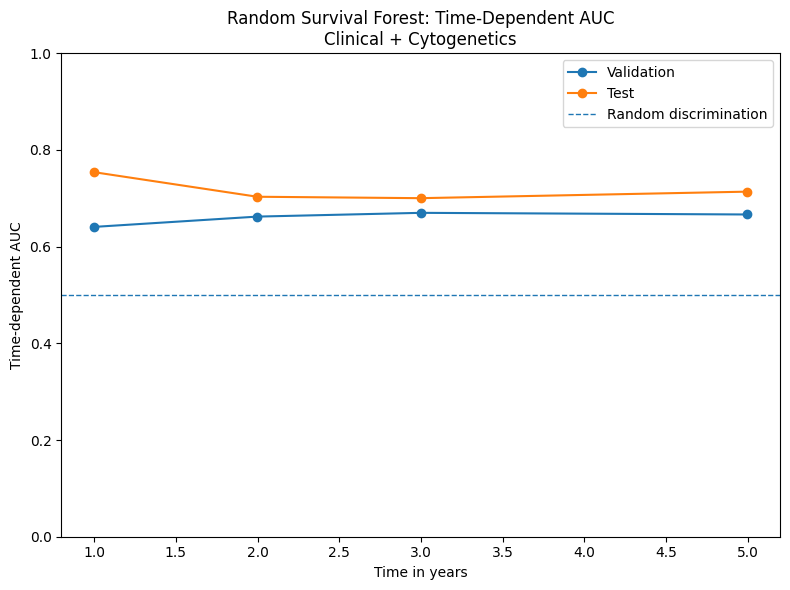

In [234]:
plt.figure(figsize=(8, 6))

plt.plot(
    validation_auc_results["time_years"],
    validation_auc_results["auc"],
    marker="o",
    label="Validation"
)

plt.plot(
    test_auc_results["time_years"],
    test_auc_results["auc"],
    marker="o",
    label="Test"
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="Random discrimination"
)

plt.xlabel("Time in years")
plt.ylabel("Time-dependent AUC")
plt.title(
    f"Random Survival Forest: Time-Dependent AUC\n"
    f"{FEATURE_SET_NAME}"
)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    f"{FEATURE_SET_NAME}_time_dependent_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [235]:
def create_brier_time_grid(
    training_df,
    evaluation_df,
    n_times=100
):
    lower = max(
        training_df[DURATION_COL].min(),
        evaluation_df[DURATION_COL].min()
    )

    upper = min(
        training_df[DURATION_COL].max(),
        evaluation_df[DURATION_COL].max()
    )

    start = max(
        lower + 1,
        evaluation_df[DURATION_COL].quantile(0.10)
    )

    stop = min(
        upper - 1,
        evaluation_df[DURATION_COL].quantile(0.90)
    )

    if start >= stop:
        raise ValueError(
            "A valid Brier-score interval could not be created."
        )

    return np.linspace(start, stop, n_times)

In [236]:
def survival_probability_matrix(model, X, times):
    survival_functions = model.predict_survival_function(X)

    matrix = np.row_stack([
        survival_function(times)
        for survival_function in survival_functions
    ])

    return matrix

In [238]:
validation_brier_times = create_brier_time_grid(
    train_selected_df,
    validation_selected_df
)

test_brier_times = create_brier_time_grid(
    train_selected_df,
    test_selected_df
)

In [239]:
validation_survival_probabilities = (
    survival_probability_matrix(
        rsf,
        X_validation,
        validation_brier_times
    )
)

test_survival_probabilities = (
    survival_probability_matrix(
        rsf,
        X_test,
        test_brier_times
    )
)

In [240]:
validation_ibs = integrated_brier_score(
    y_train,
    y_validation,
    validation_survival_probabilities,
    validation_brier_times
)

test_ibs = integrated_brier_score(
    y_train,
    y_test,
    test_survival_probabilities,
    test_brier_times
)

print("Validation IBS:", round(validation_ibs, 4))
print("Test IBS:", round(test_ibs, 4))

Validation IBS: 0.1987
Test IBS: 0.1879


In [ ]:
evaluation_summary = pd.DataFrame({
    "model": [
        "Random Survival Forest",
        "Random Survival Forest"
    ],
    "feature_set": [
        FEATURE_SET_NAME,
        FEATURE_SET_NAME
    ],
    "dataset": [
        "Validation",
        "Test"
    ],
    "n_predictors": [
        len(selected_features),
        len(selected_features)
    ],
    "n_estimators": [
        RSF_PARAMETERS["n_estimators"],
        RSF_PARAMETERS["n_estimators"]
    ],
    "max_depth": [
        str(RSF_PARAMETERS["max_depth"]),
        str(RSF_PARAMETERS["max_depth"])
    ],
    "min_samples_split": [
        RSF_PARAMETERS["min_samples_split"],
        RSF_PARAMETERS["min_samples_split"]
    ],
    "min_samples_leaf": [
        RSF_PARAMETERS["min_samples_leaf"],
        RSF_PARAMETERS["min_samples_leaf"]
    ],
    "max_features": [
        str(RSF_PARAMETERS["max_features"]),
        str(RSF_PARAMETERS["max_features"])
    ],
    "c_index": [
        validation_cindex,
        test_cindex
    ],
    "integrated_brier_score": [
        validation_ibs,
        test_ibs
    ],
    "mean_time_dependent_auc": [
        validation_mean_auc,
        test_mean_auc
    ],
    "oob_c_index_training": [
        rsf.oob_score_,
        rsf.oob_score_
    ]
})

display(evaluation_summary)

In [ ]:
safe_feature_name = (
    FEATURE_SET_NAME
    .lower()
    .replace(" + ", "_")
    .replace(" ", "_")
)

evaluation_summary.to_csv(
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_evaluation.csv",
    index=False
)

In [ ]:
def create_prediction_table(
    original_df,
    survival_outcome,
    risk_scores,
    dataset_name
):
    return pd.DataFrame({
        PATIENT_ID_COL:
            original_df[PATIENT_ID_COL].values,
        DURATION_COL:
            survival_outcome["time"],
        EVENT_COL:
            survival_outcome["event"].astype(int),
        "predicted_risk":
            risk_scores,
        "dataset":
            dataset_name,
        "feature_set":
            FEATURE_SET_NAME
    })

In [ ]:
train_predictions = create_prediction_table(
    train_selected_df,
    y_train,
    train_risk,
    "Training"
)

validation_predictions = create_prediction_table(
    validation_selected_df,
    y_validation,
    validation_risk,
    "Validation"
)

test_predictions = create_prediction_table(
    test_selected_df,
    y_test,
    test_risk,
    "Test"
)

all_predictions = pd.concat(
    [
        train_predictions,
        validation_predictions,
        test_predictions
    ],
    ignore_index=True
)

all_predictions.to_csv(
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_patient_predictions.csv",
    index=False
)

display(test_predictions.head())

In [ ]:
training_risk_cutoff = np.median(train_risk)

print("Training-derived risk cutoff:", training_risk_cutoff)

In [ ]:
def plot_km_risk_groups(
    y,
    risk_scores,
    cutoff,
    dataset_name
):
    risk_groups = np.where(
        risk_scores >= cutoff,
        "High predicted risk",
        "Low predicted risk"
    )

    plt.figure(figsize=(8, 6))

    for group in [
        "Low predicted risk",
        "High predicted risk"
    ]:
        mask = risk_groups == group

        km_time, km_survival, km_ci = (
            kaplan_meier_estimator(
                y["event"][mask],
                y["time"][mask],
                conf_type="log-log"
            )
        )

        plt.step(
            km_time,
            km_survival,
            where="post",
            label=f"{group} (n={mask.sum()})"
        )

        plt.fill_between(
            km_time,
            km_ci[0],
            km_ci[1],
            step="post",
            alpha=0.2
        )

    plt.xlabel("Time in days")
    plt.ylabel("Estimated survival probability")
    plt.title(
        f"Kaplan–Meier Survival by RSF-Predicted Risk\n"
        f"{FEATURE_SET_NAME} – {dataset_name}"
    )
    plt.ylim(0, 1.02)
    plt.legend()
    plt.tight_layout()

    filename = (
        f"rsf_{safe_feature_name}_"
        f"{dataset_name.lower()}_km.png"
    )

    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
plot_km_risk_groups(
    y_validation,
    validation_risk,
    training_risk_cutoff,
    "Validation"
)

plot_km_risk_groups(
    y_test,
    test_risk,
    training_risk_cutoff,
    "Test"
)

In [ ]:
def rsf_cindex_scorer(model, X, y):
    risk = model.predict(X)

    return concordance_index_censored(
        y["event"],
        y["time"],
        risk
    )[0]

In [ ]:
permutation_results = permutation_importance(
    rsf,
    X_validation,
    y_validation,
    scoring=rsf_cindex_scorer,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

In [ ]:
importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance_mean":
        permutation_results.importances_mean,
    "importance_std":
        permutation_results.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(importance_df)

In [ ]:
importance_df.to_csv(
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_permutation_importance.csv",
    index=False
)

In [ ]:
TOP_N = min(15, len(importance_df))

plot_df = (
    importance_df
    .head(TOP_N)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Decrease in validation C-index after permutation")
plt.ylabel("Predictor")
plt.title(
    f"RSF Permutation Feature Importance\n"
    f"{FEATURE_SET_NAME}"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
CALIBRATION_TIME = 730.0
N_CALIBRATION_GROUPS = 5

In [ ]:
def predicted_survival_at_time(
    model,
    X,
    evaluation_time
):
    survival_functions = model.predict_survival_function(X)

    return np.array([
        function(evaluation_time)
        for function in survival_functions
    ])

In [ ]:
def observed_km_survival_at_time(
    event,
    time,
    evaluation_time
):
    km_time, km_survival = kaplan_meier_estimator(
        event,
        time
    )

    valid = km_time <= evaluation_time

    if not valid.any():
        return 1.0

    return km_survival[valid][-1]

In [ ]:
def create_calibration_data(
    model,
    X,
    y,
    evaluation_time,
    n_groups=5
):
    predictions = predicted_survival_at_time(
        model,
        X,
        evaluation_time
    )

    calibration_df = pd.DataFrame({
        "predicted_survival": predictions,
        "event": y["event"],
        "time": y["time"]
    })

    calibration_df["group"] = pd.qcut(
        calibration_df["predicted_survival"],
        q=n_groups,
        duplicates="drop"
    )

    results = []

    for group, group_df in calibration_df.groupby(
        "group",
        observed=True
    ):
        observed_survival = (
            observed_km_survival_at_time(
                group_df["event"].values,
                group_df["time"].values,
                evaluation_time
            )
        )

        results.append({
            "group": str(group),
            "n": len(group_df),
            "mean_predicted_survival":
                group_df["predicted_survival"].mean(),
            "observed_survival":
                observed_survival
        })

    return pd.DataFrame(results)

In [ ]:
if CALIBRATION_TIME < test_selected_df[DURATION_COL].max():
    test_calibration = create_calibration_data(
        rsf,
        X_test,
        y_test,
        CALIBRATION_TIME,
        N_CALIBRATION_GROUPS
    )

    display(test_calibration)

    plt.figure(figsize=(7, 7))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.scatter(
        test_calibration["mean_predicted_survival"],
        test_calibration["observed_survival"],
        s=70
    )

    plt.xlabel(
        f"Mean predicted survival at "
        f"{int(CALIBRATION_TIME)} days"
    )
    plt.ylabel(
        f"Observed Kaplan–Meier survival at "
        f"{int(CALIBRATION_TIME)} days"
    )
    plt.title(
        f"RSF Calibration: Test Set\n"
        f"{FEATURE_SET_NAME}"
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        f"rsf_{safe_feature_name}_test_calibration.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    test_calibration.to_csv(
        OUTPUT_DIR /
        f"rsf_{safe_feature_name}_test_calibration.csv",
        index=False
    )

In [ ]:
PARAMETER_GRID = {
    "n_estimators": [300, 500],
    "max_depth": [None, 5],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [3, 10],
    "max_features": ["sqrt"]
}

In [ ]:
tuning_results = []

parameter_combinations = list(ParameterGrid(PARAMETER_GRID))

print(
    "Number of combinations:",
    len(parameter_combinations)
)

In [ ]:
for run_number, parameters in enumerate(
    parameter_combinations,
    start=1
):
    print(
        f"Run {run_number}/{len(parameter_combinations)}:",
        parameters
    )

    try:
        model = RandomSurvivalForest(
            **parameters,
            bootstrap=True,
            oob_score=True,
            n_jobs=-1,
            random_state=42
        )

        model.fit(X_train, y_train)

        train_prediction = model.predict(X_train)
        validation_prediction = model.predict(X_validation)

        run_train_cindex = concordance_index_censored(
            y_train["event"],
            y_train["time"],
            train_prediction
        )[0]

        run_validation_cindex = concordance_index_censored(
            y_validation["event"],
            y_validation["time"],
            validation_prediction
        )[0]

        tuning_results.append({
            **parameters,
            "train_c_index": run_train_cindex,
            "validation_c_index":
                run_validation_cindex,
            "train_validation_gap":
                run_train_cindex
                - run_validation_cindex,
            "oob_c_index":
                model.oob_score_,
            "success": True,
            "error": None
        })

    except Exception as error:
        tuning_results.append({
            **parameters,
            "train_c_index": np.nan,
            "validation_c_index": np.nan,
            "train_validation_gap": np.nan,
            "oob_c_index": np.nan,
            "success": False,
            "error": str(error)
        })

In [ ]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    [
        "validation_c_index",
        "train_validation_gap"
    ],
    ascending=[False, True]
).reset_index(drop=True)

display(tuning_results_df.head(20))

In [ ]:
tuning_results_df.to_csv(
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_hyperparameter_tuning.csv",
    index=False
)

In [ ]:
successful_results = tuning_results_df.loc[
    tuning_results_df["success"]
].copy()

best_row = successful_results.iloc[0]

best_parameters = {
    "n_estimators":
        int(best_row["n_estimators"]),
    "max_depth":
        None
        if pd.isna(best_row["max_depth"])
        else int(best_row["max_depth"]),
    "min_samples_split":
        int(best_row["min_samples_split"]),
    "min_samples_leaf":
        int(best_row["min_samples_leaf"]),
    "max_features":
        best_row["max_features"]
}

print("Selected parameters:")
print(best_parameters)

In [ ]:
best_rsf = RandomSurvivalForest(
    **best_parameters,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

best_rsf.fit(X_train, y_train)

In [ ]:
MODEL_PATH = (
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_model.pkl"
)

with open(MODEL_PATH, "wb") as file:
    pickle.dump(rsf, file)

In [ ]:
CONFIGURATION = {
    "model": "Random Survival Forest",
    "feature_set": FEATURE_SET_NAME,
    "features": selected_features,
    "parameters": RSF_PARAMETERS,
    "duration_column": DURATION_COL,
    "event_column": EVENT_COL,
    "random_state": 42
}

CONFIG_PATH = (
    OUTPUT_DIR /
    f"rsf_{safe_feature_name}_configuration.json"
)

with open(CONFIG_PATH, "w") as file:
    json.dump(
        CONFIGURATION,
        file,
        indent=4
    )

print("Model saved to:", MODEL_PATH)
print("Configuration saved to:", CONFIG_PATH)